# Network Intrusion Detection Project (Complete)



In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load data
csv_path = Path("dataset") / "network_traffic.csv"
df = pd.read_csv(csv_path)

feature_cols = [c for c in df.columns if c != "label"]
X = df[feature_cols].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Dataset shape: {df.shape}")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print("\nClass distribution:")
print(y.value_counts().sort_index())

Dataset shape: (6000, 16)
Train shape: (4800, 15) | Test shape: (1200, 15)

Class distribution:
label
0    3000
1    3000
Name: count, dtype: int64


## Task 1: Data Exploration

In this section, I inspect the class balance and feature behavior before training any model. Since all columns are numeric and the dataset is balanced, preprocessing is straightforward.

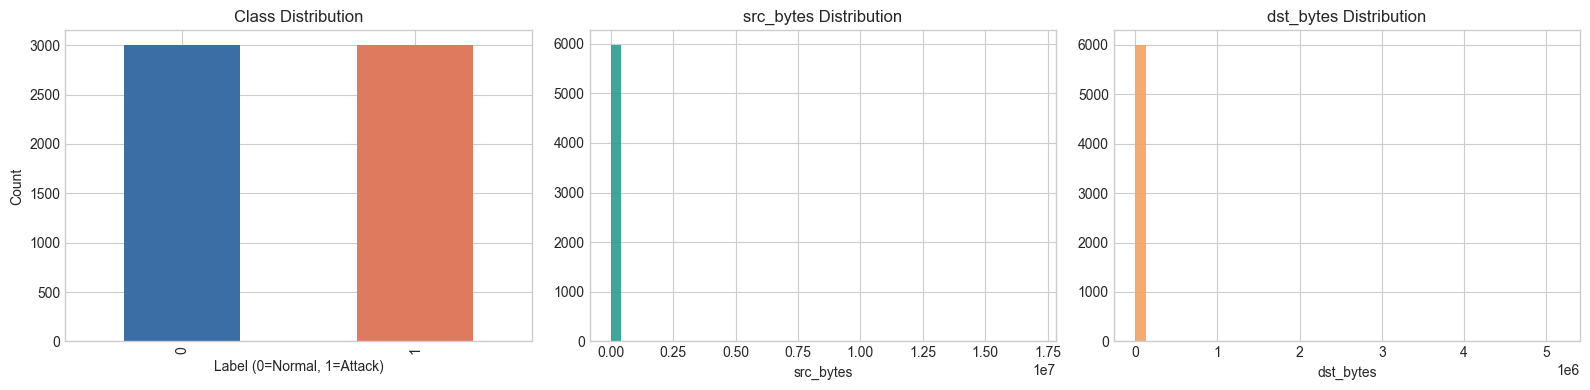

,mean,std,min,max
duration,413.933,3237.030,0.0,42569.0
src_bytes,16033.066,304975.376,0.0,16980503.0
dst_bytes,2951.740,70573.656,0.0,5149533.0
wrong_fragment,0.028,0.284,0.0,3.0
hot,0.206,2.121,0.0,30.0
logged_in,0.385,0.487,0.0,1.0
num_compromised,0.180,8.981,0.0,520.0
count,80.434,108.869,0.0,511.0
srv_count,27.572,70.945,0.0,511.0
serror_rate,0.294,0.452,0.0,1.0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
(y.value_counts().sort_index()).plot(kind="bar", ax=axes[0], color=["#3A6EA5", "#E07A5F"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label (0=Normal, 1=Attack)")
axes[0].set_ylabel("Count")

# Feature distributions
axes[1].hist(df["src_bytes"], bins=40, color="#2A9D8F", alpha=0.9)
axes[1].set_title("src_bytes Distribution")
axes[1].set_xlabel("src_bytes")

axes[2].hist(df["dst_bytes"], bins=40, color="#F4A261", alpha=0.9)
axes[2].set_title("dst_bytes Distribution")
axes[2].set_xlabel("dst_bytes")

plt.tight_layout()
plt.show()

display(df[feature_cols].describe().T[["mean", "std", "min", "max"]].round(3).head(10))

## Task 2: Simple Reflex Agent

A reflex agent uses fixed if-then rules instead of learning from data. Here, I designed practical network-security rules based on suspicious indicators (for example high error rate, wrong fragments, and compromise markers).

Reflex Agent Classification Report:
              precision    recall  f1-score   support

           0     0.7879    0.9783    0.8729       600
           1     0.9714    0.7367    0.8379       600

    accuracy                         0.8575      1200
   macro avg     0.8797    0.8575    0.8554      1200
weighted avg     0.8797    0.8575    0.8554      1200



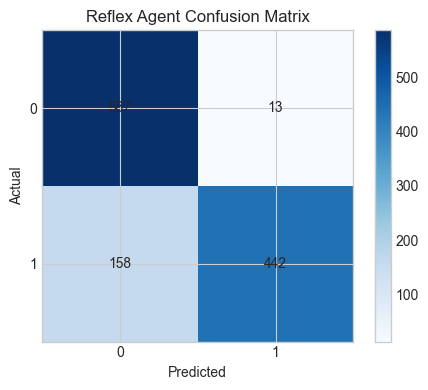

In [4]:
def reflex_agent_predict(X_input: pd.DataFrame) -> np.ndarray:
    preds = []
    for _, row in X_input.iterrows():
        is_attack = (
            (row["wrong_fragment"] > 0)
            or (row["hot"] >= 5)
            or (row["num_compromised"] > 0)
            or ((row["logged_in"] == 0) and (row["serror_rate"] >= 0.5))
            or ((row["src_bytes"] == 0) and (row["dst_bytes"] == 0) and (row["count"] > 100))
        )
        preds.append(1 if is_attack else 0)
    return np.array(preds)


y_pred_reflex = reflex_agent_predict(X_test)

reflex_metrics = {
    "model": "Simple Reflex Agent",
    "accuracy": accuracy_score(y_test, y_pred_reflex),
    "precision": precision_score(y_test, y_pred_reflex, zero_division=0),
    "recall": recall_score(y_test, y_pred_reflex, zero_division=0),
    "f1": f1_score(y_test, y_pred_reflex, zero_division=0),
}

print("Reflex Agent Classification Report:")
print(classification_report(y_test, y_pred_reflex, digits=4))

cm_reflex = confusion_matrix(y_test, y_pred_reflex)
plt.figure(figsize=(5, 4))
plt.imshow(cm_reflex, cmap="Blues")
plt.title("Reflex Agent Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_reflex[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

## Task 3: Supervised Classifiers

This section compares KNN, Naive Bayes, and Logistic Regression on the same train/test split. I tune KNN with cross-validation to avoid picking k arbitrarily.

In [5]:
# Tune KNN (odd k values)
k_values = list(range(1, 22, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_k = None
best_cv_score = -1
for k in k_values:
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    score = cross_val_score(knn_pipe, X_train, y_train, cv=cv, scoring="f1").mean()
    if score > best_cv_score:
        best_cv_score = score
        best_k = k

print(f"Best k from CV: {best_k} (mean F1={best_cv_score:.4f})")

models = {
    f"KNN (k={best_k})": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]),
}

supervised_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    supervised_results.append(row)
    trained_models[name] = model

comparison_df = pd.DataFrame([reflex_metrics] + supervised_results).sort_values(by="f1", ascending=False)
comparison_df

Best k from CV: 1 (mean F1=0.9585)


,model,accuracy,precision,recall,f1
1,KNN (k=1),0.9575,0.949264,0.966667,0.957886
3,Logistic Regression,0.9150,0.924915,0.903333,0.913997
0,Simple Reflex Agent,0.8575,0.971429,0.736667,0.837915
2,Naive Bayes,0.7875,0.936709,0.616667,0.743719


## Task 4: Clustering with K-Means

K-Means is unsupervised, so cluster IDs are arbitrary. I map each cluster to a class label by majority vote on the training set, then evaluate on the test set.

Cluster to label mapping: {0: 1, 1: 0}
K-Means mapped accuracy: 0.8533


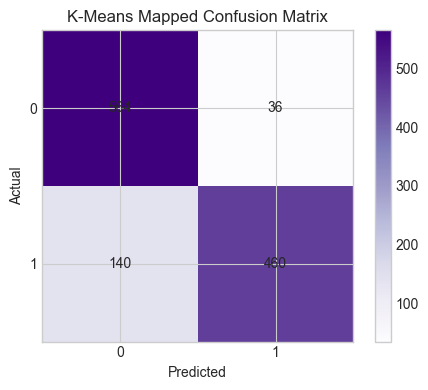

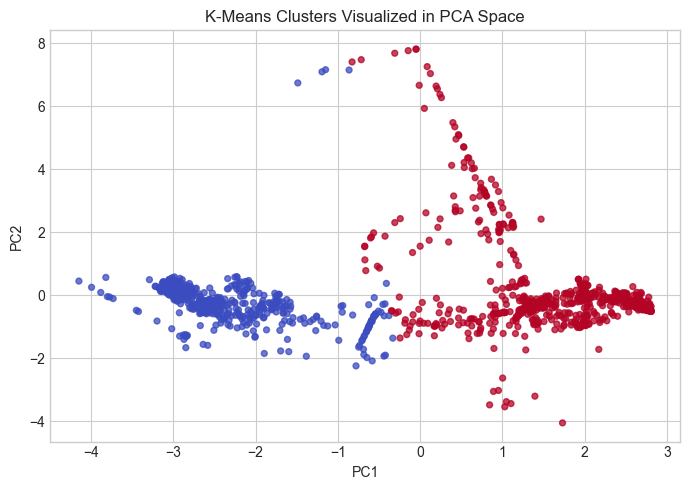

In [6]:
# Scale before K-Means
scaler_km = StandardScaler()
X_train_scaled = scaler_km.fit_transform(X_train)
X_test_scaled = scaler_km.transform(X_test)

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=20)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# Map cluster id -> class label using training majority vote
cluster_to_label = {}
for c in [0, 1]:
    major_label = y_train[train_clusters == c].mode().iloc[0]
    cluster_to_label[c] = int(major_label)

kmeans_pred = np.array([cluster_to_label[c] for c in test_clusters])

kmeans_metrics = {
    "model": "K-Means (mapped)",
    "accuracy": accuracy_score(y_test, kmeans_pred),
    "precision": precision_score(y_test, kmeans_pred, zero_division=0),
    "recall": recall_score(y_test, kmeans_pred, zero_division=0),
    "f1": f1_score(y_test, kmeans_pred, zero_division=0),
}

print("Cluster to label mapping:", cluster_to_label)
print("K-Means mapped accuracy:", round(kmeans_metrics["accuracy"], 4))

cm_kmeans = confusion_matrix(y_test, kmeans_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm_kmeans, cmap="Purples")
plt.title("K-Means Mapped Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_kmeans[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

# PCA scatter for visualization
pca = PCA(n_components=2, random_state=SEED)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=test_clusters, cmap="coolwarm", s=18, alpha=0.75)
plt.title("K-Means Clusters Visualized in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Task 5: Genetic Algorithm for Feature Selection

I use a custom binary genetic algorithm where each chromosome represents selected features. Fitness is validation F1-score of a Logistic Regression model trained on only the selected subset.

Best GA validation F1: 0.9130
Selected 11 features out of 15
['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'logged_in', 'count', 'serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate']


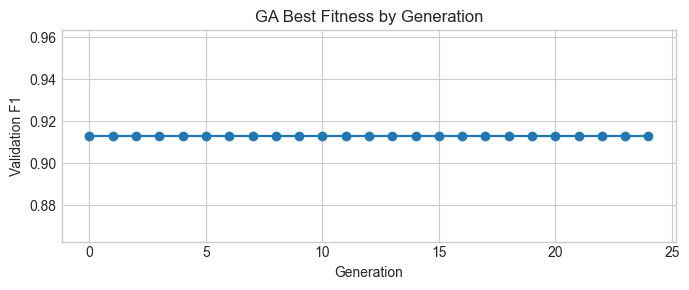

,setting,accuracy,f1
0,Logistic (all features),0.915000,0.913997
1,Logistic (GA-selected features),0.913333,0.914333


In [7]:
# Train/validation split for GA fitness
X_ga_train, X_ga_val, y_ga_train, y_ga_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
)

n_features = len(feature_cols)


def fitness(chromosome):
    idx = [i for i, bit in enumerate(chromosome) if bit == 1]
    if len(idx) == 0:
        return 0.0

    selected_cols = [feature_cols[i] for i in idx]
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1200, random_state=SEED)),
    ])
    model.fit(X_ga_train[selected_cols], y_ga_train)
    pred = model.predict(X_ga_val[selected_cols])
    return f1_score(y_ga_val, pred, zero_division=0)


POP_SIZE = 40
GENERATIONS = 25
MUTATION_RATE = 0.08
ELITE = 4

population = [np.random.randint(0, 2, size=n_features).tolist() for _ in range(POP_SIZE)]

best_chromosome = None
best_fitness = -1
history = []

for _ in range(GENERATIONS):
    scored = [(chrom, fitness(chrom)) for chrom in population]
    scored.sort(key=lambda x: x[1], reverse=True)

    if scored[0][1] > best_fitness:
        best_chromosome, best_fitness = scored[0][0][:], scored[0][1]

    history.append(scored[0][1])

    next_pop = [scored[i][0][:] for i in range(ELITE)]

    def tournament_pick(k=4):
        candidates = random.sample(scored, k)
        candidates.sort(key=lambda x: x[1], reverse=True)
        return candidates[0][0][:]

    while len(next_pop) < POP_SIZE:
        p1 = tournament_pick()
        p2 = tournament_pick()

        cut = random.randint(1, n_features - 1)
        c1 = p1[:cut] + p2[cut:]
        c2 = p2[:cut] + p1[cut:]

        for c in (c1, c2):
            for i in range(n_features):
                if random.random() < MUTATION_RATE:
                    c[i] = 1 - c[i]

        next_pop.extend([c1, c2])

    population = next_pop[:POP_SIZE]

selected_idx = [i for i, b in enumerate(best_chromosome) if b == 1]
selected_features = [feature_cols[i] for i in selected_idx]

print(f"Best GA validation F1: {best_fitness:.4f}")
print(f"Selected {len(selected_features)} features out of {n_features}")
print(selected_features)

# Evaluate Logistic Regression with selected GA features vs all features
ga_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=SEED)),
])

all_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=SEED)),
])

ga_model.fit(X_train[selected_features], y_train)
all_model.fit(X_train[feature_cols], y_train)

y_pred_ga = ga_model.predict(X_test[selected_features])
y_pred_all = all_model.predict(X_test[feature_cols])

ga_vs_all_df = pd.DataFrame([
    {
        "setting": "Logistic (all features)",
        "accuracy": accuracy_score(y_test, y_pred_all),
        "f1": f1_score(y_test, y_pred_all),
    },
    {
        "setting": "Logistic (GA-selected features)",
        "accuracy": accuracy_score(y_test, y_pred_ga),
        "f1": f1_score(y_test, y_pred_ga),
    },
])

plt.figure(figsize=(7, 3))
plt.plot(history, marker="o", linewidth=1.6)
plt.title("GA Best Fitness by Generation")
plt.xlabel("Generation")
plt.ylabel("Validation F1")
plt.tight_layout()
plt.show()

ga_vs_all_df

In [8]:
# Final project summary table
final_table = pd.concat([
    comparison_df,
    pd.DataFrame([kmeans_metrics]),
], ignore_index=True).sort_values(by="f1", ascending=False)

display(final_table)

best_row = final_table.iloc[0]
print(
    f"Best overall method: {best_row['model']} | "
    f"Accuracy={best_row['accuracy']:.4f}, F1={best_row['f1']:.4f}"
)

,model,accuracy,precision,recall,f1
0,KNN (k=1),0.957500,0.949264,0.966667,0.957886
1,Logistic Regression,0.915000,0.924915,0.903333,0.913997
4,K-Means (mapped),0.853333,0.927419,0.766667,0.839416
2,Simple Reflex Agent,0.857500,0.971429,0.736667,0.837915
3,Naive Bayes,0.787500,0.936709,0.616667,0.743719


Best overall method: KNN (k=1) | Accuracy=0.9575, F1=0.9579


In [9]:
# Export key results for report usage
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

comparison_df.to_csv(output_dir / "task3_supervised_comparison.csv", index=False)
final_table.to_csv(output_dir / "final_model_ranking.csv", index=False)
ga_vs_all_df.to_csv(output_dir / "task5_ga_vs_all.csv", index=False)

print("Saved result tables to outputs/ folder")

Saved result tables to outputs/ folder


## Discussion and Conclusion

- The rule-based reflex agent is interpretable but limited, because static rules cannot capture complex feature interactions.
- Supervised learning gave stronger and more stable performance, with Logistic Regression and KNN benefiting from scaling.
- K-Means worked reasonably after cluster-label mapping, but it still lagged behind supervised models because no labels are used during training.
- Genetic feature selection produced a compact subset and showed whether all features are truly necessary.

Overall, this project demonstrates a full journey from simple AI rules to data-driven machine learning and optimization-based feature engineering.